В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [1]:
import pandas as pd
medical_df = pd.read_csv('C:\\Users\\livet\\ML_course\\Materials\\medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [2]:
import numpy as np
non_smoker_df.head()

x = non_smoker_df[['age']].values
x_intercept = np.c_[np.ones((x.shape[0], 1)), x]
y = non_smoker_df['charges'].values.reshape(-1, 1)

def normal_equations(X,y):
    
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [3]:
mnk_coefs = normal_equations(x_intercept, y)
mnk_coefs

array([[-2091.42055657],
       [  267.24891283]])

In [4]:
np.dot(x_intercept[0], mnk_coefs)

array([2719.0598744])

In [5]:
mnk_prediction = np.dot(x_intercept, mnk_coefs)
mnk_prediction[:4], y[:4]

(array([[2719.0598744 ],
        [5391.54900271],
        [6727.79356686],
        [6460.54465403]]),
 array([[ 1725.5523 ],
        [ 4449.462  ],
        [21984.47061],
        [ 3866.8552 ]]))

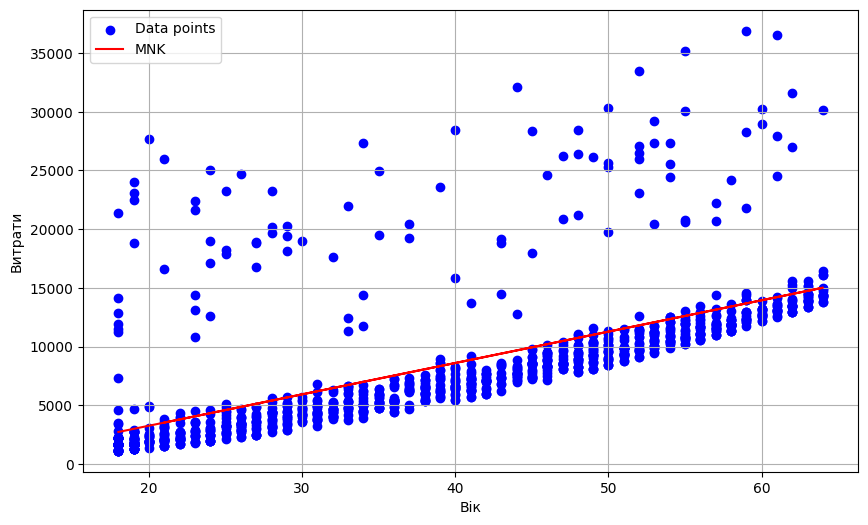

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(x[:, 0], y, color='blue', label='Data points')
plt.plot(x[:, 0], mnk_prediction, color='red', label='MNK')
plt.xlabel('Вік')
plt.ylabel('Витрати')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 1] + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X[:, 1])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors


In [8]:
m1, b1, errors1 = full_batch_gradient_descent(x_intercept, y.flatten(), lr=0.1, epochs=1000)
print("lr=0.1:", m1, b1)

m2, b2, errors2 = full_batch_gradient_descent(x_intercept, y.flatten(), lr=0.0001, epochs=200000)
print("lr=0.0001:", m2, b2)

m3, b3, errors3 = full_batch_gradient_descent(x_intercept, y.flatten(), lr=0.00001, epochs=200000)
print("lr=0.00001:", m3, b3)

C:\Users\livet\AppData\Local\Temp\ipykernel_2168\3419479804.py:8: RuntimeWarning: overflow encountered in square
  errors.append(sum(error**2))
C:\Users\livet\AppData\Local\Temp\ipykernel_2168\3419479804.py:8: RuntimeWarning: overflow encountered in scalar add
  errors.append(sum(error**2))
C:\Users\livet\AppData\Local\Temp\ipykernel_2168\3419479804.py:9: RuntimeWarning: overflow encountered in dot
  m_gradient = (2/n) * np.dot(error, X[:, 1])
C:\Users\livet\AppData\Local\Temp\ipykernel_2168\3419479804.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient


lr=0.1: nan nan
lr=0.0001: 266.7393863144744 -2068.7906105520456
lr=0.00001: 237.23824121686818 -758.536288220586


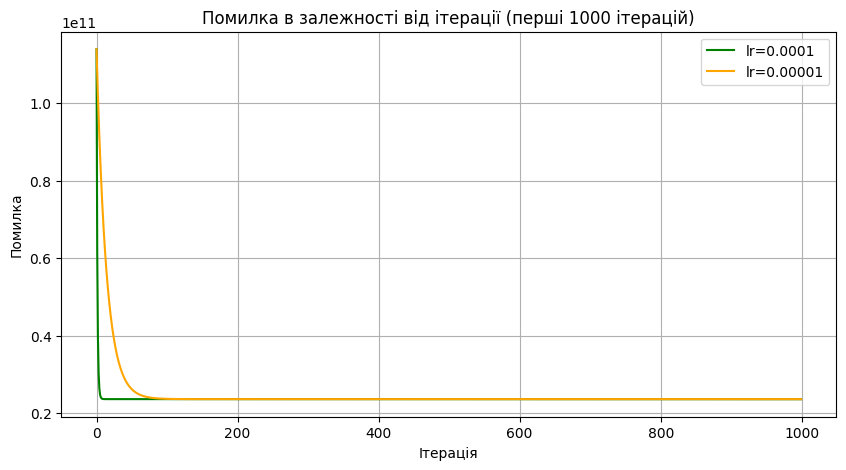

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(errors2[:1000], label='lr=0.0001', color='green')
plt.plot(errors3[:1000], label='lr=0.00001', color='orange')
plt.xlabel('Ітерація')
plt.ylabel('Помилка')
plt.title('Помилка в залежності від ітерації (перші 1000 ітерацій)')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression

x_sklearn = non_smoker_df[['age']]
lin_reg = LinearRegression()
lin_reg.fit(x_sklearn, y)

print("Коефіцієнт (m):", lin_reg.coef_)
print("Зсув (b):", lin_reg.intercept_)
sklearn_prediction = lin_reg.predict(x_sklearn)

Коефіцієнт (m): [[267.24891283]]
Зсув (b): [-2091.42055657]


In [11]:
from sklearn.metrics import mean_squared_error

rmse_mnk = np.sqrt(np.mean((y.flatten() - mnk_prediction.flatten())**2))

predictions_fbgd = m2 * non_smoker_df['age'].values + b2
rmse_fbgd = np.sqrt(np.mean((y.flatten() - predictions_fbgd)**2))
print('RMSE МНК:', rmse_mnk)
print('RMSE Град. спуск:', rmse_fbgd)

rmse_sklearn = np.sqrt(mean_squared_error(y, sklearn_prediction))
print('RMSE Sklearn:', rmse_sklearn)

RMSE МНК: 4662.505766636395
RMSE Град. спуск: 4662.511987422228
RMSE Sklearn: 4662.505766636395


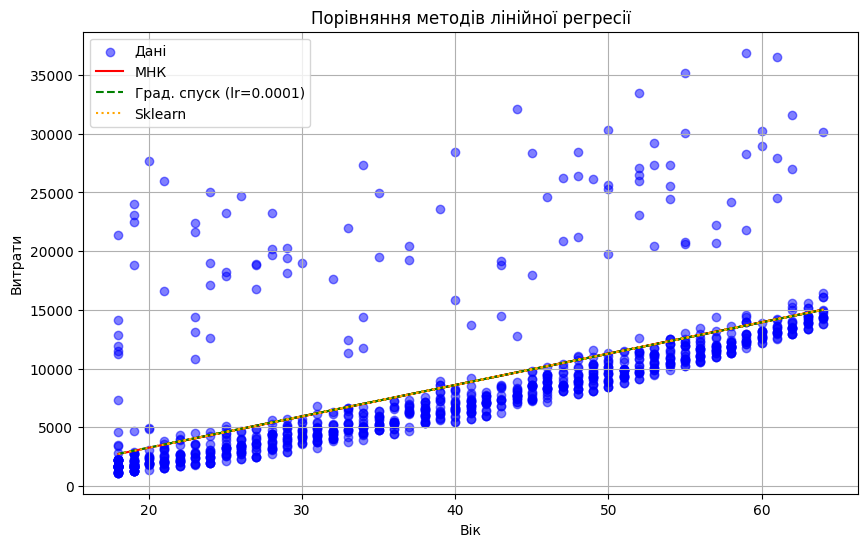

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(non_smoker_df['age'], y, color='blue', label='Дані', alpha=0.5)
plt.plot(non_smoker_df['age'], mnk_prediction, color='red', label='МНК')
plt.plot(non_smoker_df['age'], predictions_fbgd, color='green', linestyle='--', label='Град. спуск (lr=0.0001)')
plt.plot(non_smoker_df['age'], sklearn_prediction, color='orange', linestyle=':', label='Sklearn')
plt.xlabel('Вік')
plt.ylabel('Витрати')
plt.title('Порівняння методів лінійної регресії')
plt.legend()
plt.grid(True)
plt.show()

### Висновки до завдання 1 

Всі 3 методи знайшли майже однакову лінію регресії зі значенням m ~ 267 і b~ -2091. Згідно m ~ 267 можна зробити висновок, що витрати зростають на 267 доларів щорічно. 

RMSE для 3 методів теж майже однаовий - мнк та scikit-learn.LinearRegression дають однаковий RMSE (4662.505766636395), для градієнтного спуску значення близьке і становить 4662.511987422228.

Щодо learning rate - брала значення lr 0.1, 0.0001, 0.00001:
- lr=0.1 розходиться (nan), надто великий крок
- lr=0.0001 вийшов найкращий: швидко збігається і дає найточніший результат
- lr=0.00001 збігається надто повільно, за 200000 ітерацій не досягає оптимуму\

В цілому можна зробити висновок що існує тенденція зростання витрат з віком, проте RMSE в приблизно 4662 доларів це великий розкид даних. Тож лінійна регресія за однією ознакою (в нашому випрадку вік) не буде найкращою моделлю тут.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [13]:
smoker_df = medical_df[medical_df.smoker == 'yes']
X_smoker = smoker_df[['age']]
y_smoker = smoker_df['charges']

In [14]:
lin_reg_smoker = LinearRegression()
lin_reg_smoker.fit(X_smoker, y_smoker)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
print('Коефіцієнт (m):', lin_reg_smoker.coef_)
print('Зсув (b):', lin_reg_smoker.intercept_)

Коефіцієнт (m): [305.23760211]
Зсув (b): 20294.12812691597


In [16]:
predictions_smoker = lin_reg_smoker.predict(X_smoker)
rmse_smoker = np.sqrt(mean_squared_error(y_smoker, predictions_smoker))
print('RMSE:', rmse_smoker)

RMSE: 10711.00334810241


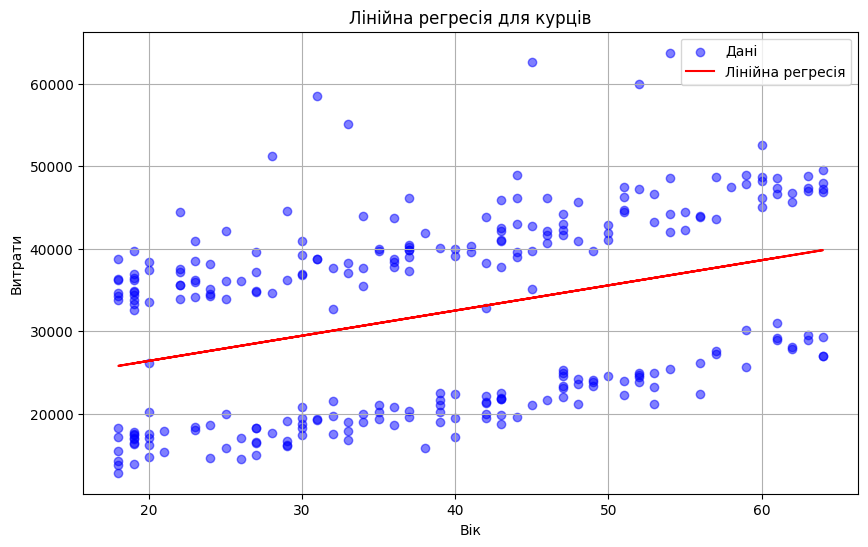

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(smoker_df['age'], y_smoker, color='blue', label='Дані', alpha=0.5)
plt.plot(smoker_df['age'], predictions_smoker, color='red', label='Лінійна регресія')
plt.xlabel('Вік')
plt.ylabel('Витрати')
plt.title('Лінійна регресія для курців')
plt.legend()
plt.grid(True)
plt.show()

### Висновки до завдання 2 

Було отримано наступні результати: m ~ 305, b ~ 20294, отже можна зробити висновок що витрати зростають на 305 доларів щорічно

RMSE становить приблизно 10711 доларів, що вдвічі більше за некурців. 
На графіку бачимо що у нас виходить 2 окремих кластери, тож лінія, яка розташувалась між ними не може описати дві групи одночасно. 

Як висновок - я би йю модель не використовувала оскільки вона дуже неточна. Можна було б спробувати додати більше ознак, тоді можливо результат був би кращий 